In [1]:
import os
import re
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import pickle
import matplotlib.pyplot as plt
import hashlib
from collections import defaultdict

In [2]:
base_path = os.getcwd()
file_name = 'experiment_v3_cifar10/exp5_repeat_1/data_QNAS.pkl'
file_name2 = 'experiment_v3_cifar10/exp6_repeat_1/data_QNAS.pkl'
file_path = os.path.join(base_path, file_name)

In [3]:
def read_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

data_1 = read_data(file_path)
data_2 = read_data(file_name2)

In [5]:
def get_operator_names(config_path: str):
    """
    Parses the log_params_evolution.txt file to get the operator names.
    """
    try:
        with open(config_path, 'r') as f:
            content = f.read()
        match = re.search(r"fn_list:\s*\[([^\]]+)\]", content)
        if match:
            names_str = match.group(1)
            return [name.strip().strip("'\"") for name in names_str.split(',')]
        return None
    except Exception:
        return None

In [6]:
def evolution_time(data):
    date_format = "%Y-%m-%d %H:%M:%S.%f"
    start_time = data[0]['time']
    last_key = list(data.keys())[-1]
    end_time = data[last_key]['time']
    
    start_time = datetime.strptime(start_time, date_format)
    end_time = datetime.strptime(end_time, date_format)
    
    elapsed_time = end_time - start_time
    return elapsed_time

elapsed_time_1 = evolution_time(data_1)
elapsed_time_2 = evolution_time(data_2)

print(f"Elapsed time for data 1: {elapsed_time_1}")
print(f"Elapsed time for data 2: {elapsed_time_2}")

Elapsed time for data 1: 13:06:20.139190
Elapsed time for data 2: 1 day, 18:36:51.142376


In [7]:
def plot_individual(
    data,
    generations,
    individual_idx,
    labels,
    palette=None,
    figsize=(14,6),
    bar_width=0.8
):
    """
    Plots stacked bar charts with small gaps, custom colors, and adjustable figure size.

    Args:
        data (dict): your data dict where data[gen]['net_probs'] is shape (5,20,11)
        generations (list of int): e.g. [0, last_gen]
        individual_idx (int): which individual to plot (0–4)
        labels (list of str]): length-11 list of operator names
        palette (dict): optional mapping label → hex color
        figsize (tuple): (width, height) in inches
        bar_width (float): width of each bar (0.5 → big gaps, 0.9 → small gaps)
    """
    n_gens = len(generations)
    fig, axes = plt.subplots(n_gens, 1, figsize=figsize, sharex=True, sharey=True)
    if n_gens == 1:
        axes = [axes]

    # Build a list of colors in the same order as `labels`
    if palette:
        colors = [palette[label] for label in labels]
    else:
        colors = None  # let pandas choose

    for ax, gen in zip(axes, generations):
        probs = data[gen]['net_probs'][individual_idx]  # (20,11)
        df = pd.DataFrame(probs, columns=labels)

        df.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            width=bar_width,
            edgecolor='white',
            linewidth=0.5,
            color=colors,
            legend=False
        )

        ax.set_ylabel('Probability', fontsize=12)
        ax.set_title(f'Individual {individual_idx} – Generation {gen}', fontsize=12, fontweight='bold')
        ax.set_xticks(np.arange(probs.shape[0]))
        ax.set_xticklabels(np.arange(probs.shape[0]), rotation=0)

    axes[-1].set_xlabel('Network nodes', fontsize=12)

    # One legend on top plot
    axes[0].legend(
        labels,
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        title='Functions'
    )

    plt.tight_layout()
    plt.show()


In [8]:
config_path = 'experiment_v3_cifar10/exp5_repeat_1/log_params_evolution.txt'
GENERATION_TO_PLOT = [0, max(data_1.keys())]
INDIVIDUAL_TO_PLOT = 0  # Index from 0 to 4
operator_labels = get_operator_names(config_path)

In [9]:
my_palette = {
    'avg_pool_2_2':   '#4C72B0',
    'conv_1_1_32':    '#C44E52',
    'conv_1_1_64':    '#DD8452',
    'conv_3_1_32':    '#E15759',
    'conv_3_1_64':    '#EDC948',
    'conv_3_1_128':   '#4E5F56',
    'conv_3_1_256':   '#55A868',
    'conv_5_1_32':    '#4BACC6',
    'conv_5_1_64':    '#4C72B0',
    'max_pool_2_2':   '#8172B2',
    'no_op':          '#3E2F5B',
}

labels = list(my_palette.keys())

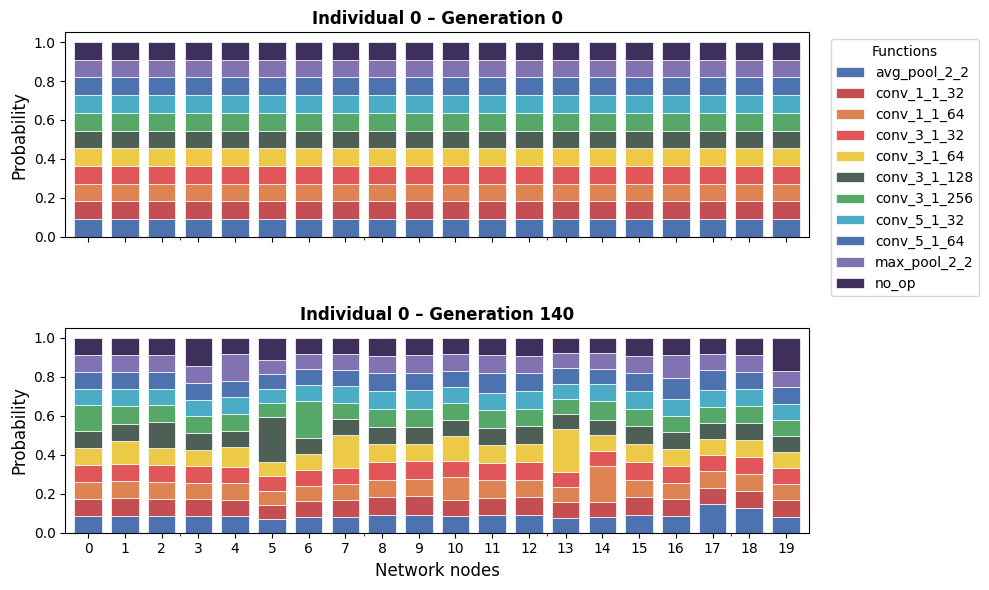

In [10]:
# 2. Pick your two generations (first and last):
gens = [0, max(data_2.keys())]

# 3. Call the plot function, tweaking figsize to taste:
plot_individual(
    data_2,
    generations=gens,
    individual_idx=0,
    labels=labels,
    palette=my_palette,
    figsize=(10, 6),   # try wider (e.g. 18×6) or taller (12×10)
    bar_width=0.75     # adjust gap size
)

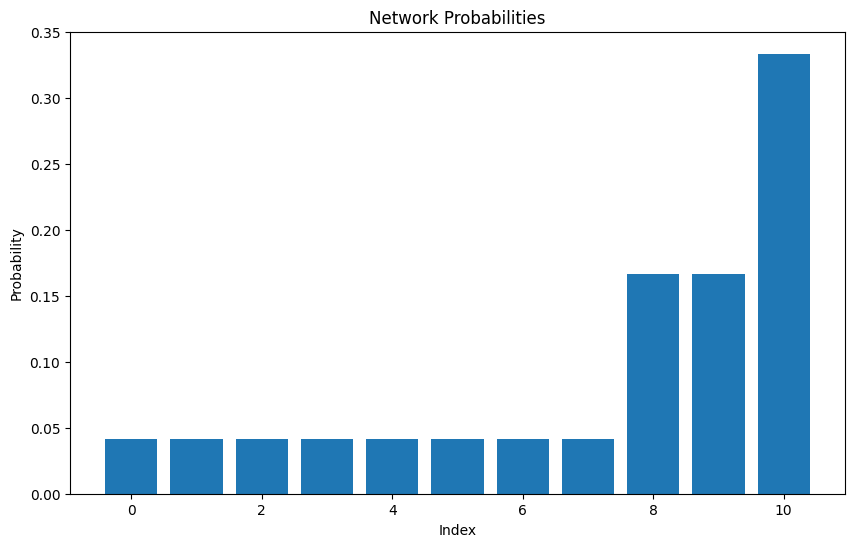

In [6]:
import matplotlib.pyplot as plt
import numpy as np

net_probs = data_1[0]['net_probs'][0][0]
sorted_probs = np.sort(net_probs.flatten())

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_probs)), sorted_probs)
plt.title('Network Probabilities')
plt.xlabel('Index')
plt.ylabel('Probability')
plt.show()

In [27]:
net_probs = data_2[20]['net_probs'][4][5]
net_probs

array([0.09090909, 0.09090909, 0.09090909, 0.09090909, 0.09090909,
       0.09090909, 0.09090909, 0.09090909, 0.09090909, 0.09090909,
       0.09090909])

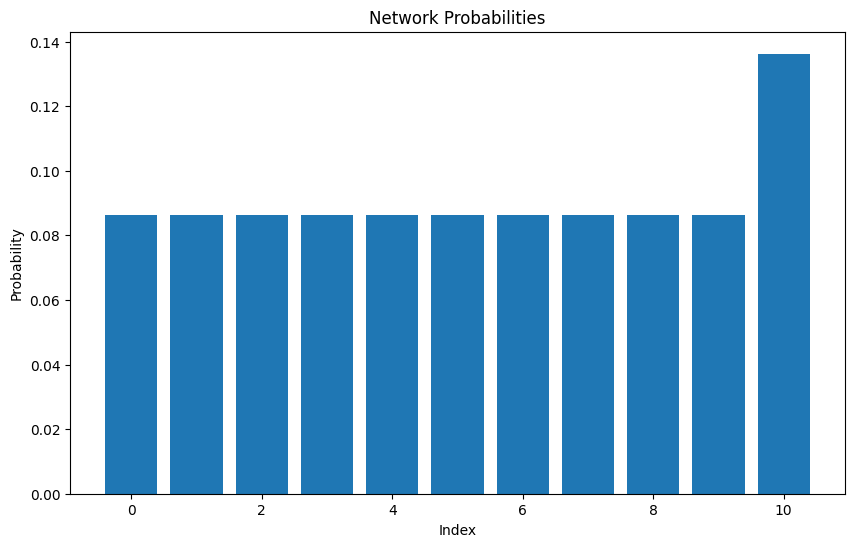

In [20]:
net_probs = data_2[20]['net_probs'][4][0]
sorted_probs = np.sort(net_probs.flatten())

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_probs)), sorted_probs)
plt.title('Network Probabilities')
plt.xlabel('Index')
plt.ylabel('Probability')
plt.show()

Figure saved as: figure_1_non_dominated_sorting.png


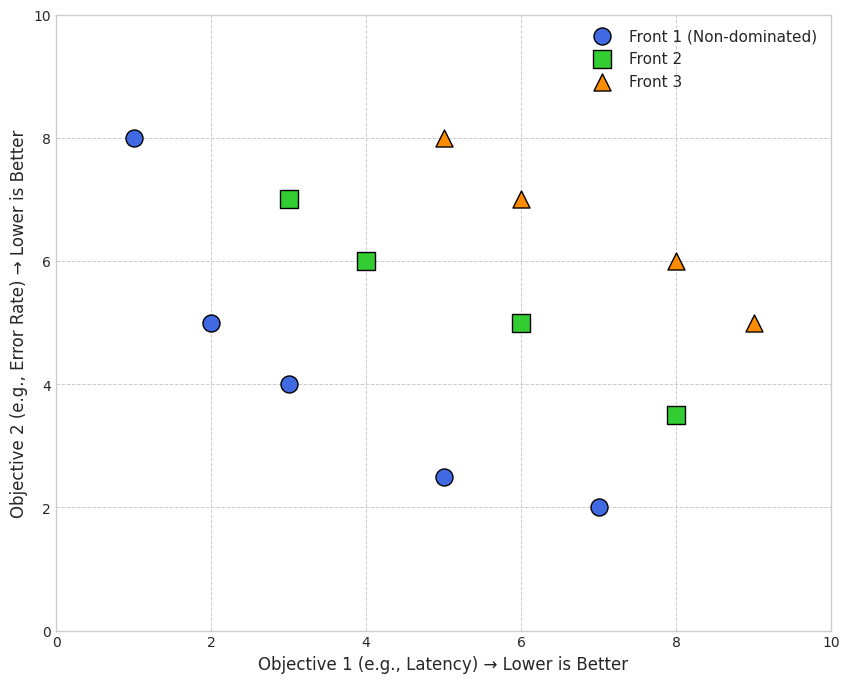

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data for the plot ---
# Define points for three distinct Pareto fronts
front1 = np.array([[1, 8], [2, 5], [3, 4], [5, 2.5], [7, 2]])
front2 = np.array([[3, 7], [4, 6], [6, 5], [8, 3.5]])
front3 = np.array([[5, 8], [6, 7], [8, 6], [9, 5]])

# --- Create the plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

# Plot each front with different markers and colors
ax.scatter(front1[:, 0], front1[:, 1], s=150, c='royalblue', edgecolor='black', marker='o', label='Front 1 (Non-dominated)')
ax.scatter(front2[:, 0], front2[:, 1], s=150, c='limegreen', edgecolor='black', marker='s', label='Front 2')
ax.scatter(front3[:, 0], front3[:, 1], s=150, c='darkorange', edgecolor='black', marker='^', label='Front 3')

# --- Formatting and Labels ---
#ax.set_title('Figure 1: Non-Dominated Sorting', fontsize=16, weight='bold')
ax.set_xlabel('Objective 1 (e.g., Latency) → Lower is Better', fontsize=12)
ax.set_ylabel('Objective 2 (e.g., Error Rate) → Lower is Better', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)

# Set axis limits
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# --- Save the figure ---
output_filename = 'figure_1_non_dominated_sorting.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"Figure saved as: {output_filename}")
plt.show()

Figure saved as: figure_2_crowding_distance_v2.png


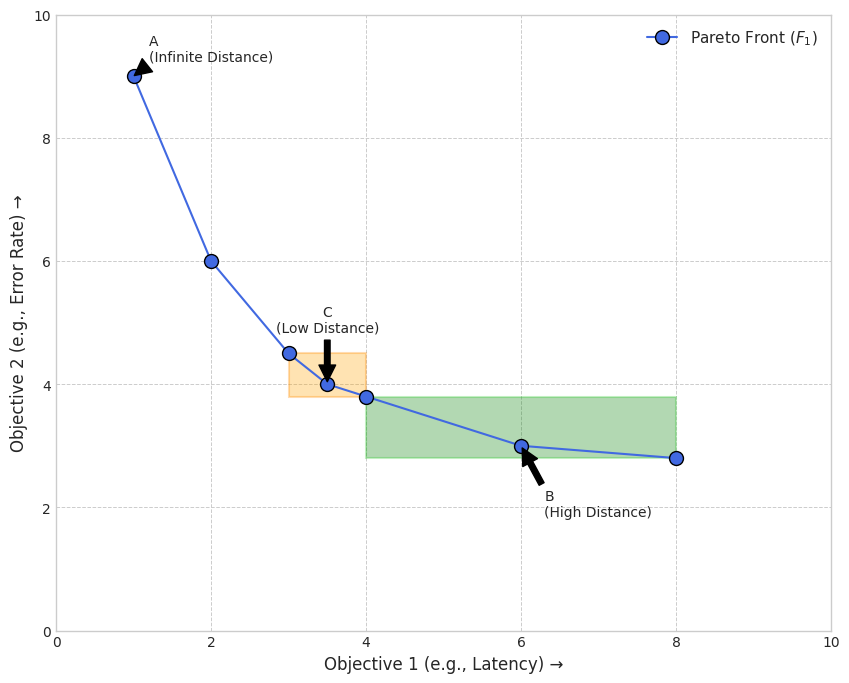

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# --- Data for the plot ---
# Define points on a single Pareto front
front = np.array([[1, 9], [2, 6], [3, 4.5], [3.5, 4], [4, 3.8], [6, 3], [8, 2.8]])

# Sort points for line plotting
front = front[front[:, 0].argsort()]

# --- Create the plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the front
ax.plot(front[:, 0], front[:, 1], 'o-', c='royalblue', markersize=10, markerfacecolor='royalblue', markeredgecolor='black', label='Pareto Front ($F_1$)')

# --- Highlight points and draw crowding distance boxes ---
# Point C (dense region)
point_c_idx = 3
p_c = front[point_c_idx]
p_c_prev = front[point_c_idx - 1]
p_c_next = front[point_c_idx + 1]
rect_c = Rectangle((p_c_prev[0], p_c_next[1]), p_c_next[0] - p_c_prev[0], p_c_prev[1] - p_c_next[1],
                linewidth=1.5, edgecolor='darkorange', facecolor='orange', alpha=0.3)
ax.add_patch(rect_c)
# MODIFIED: Moved text up and centered
ax.annotate('C\n(Low Distance)', xy=p_c, xytext=(p_c[0], p_c[1] + 0.8),
            ha='center', va='bottom', arrowprops=dict(facecolor='black', shrink=0.05))

# Point A (sparse region / boundary)
point_a_idx = 0
p_a = front[point_a_idx]
# MODIFIED: Moved text slightly right and up for better spacing
ax.annotate('A\n(Infinite Distance)', xy=p_a, xytext=(p_a[0] + 0.2, p_a[1] + 0.2),
            ha='left', va='bottom', arrowprops=dict(facecolor='black', shrink=0.05))

# Point B (sparse region)
point_b_idx = 5
p_b = front[point_b_idx]
p_b_prev = front[point_b_idx - 1]
p_b_next = front[point_b_idx + 1]
rect_b = Rectangle((p_b_prev[0], p_b_next[1]), p_b_next[0] - p_b_prev[0], p_b_prev[1] - p_b_next[1],
                linewidth=1.5, edgecolor='limegreen', facecolor='green', alpha=0.3)
ax.add_patch(rect_b)
# MODIFIED: Moved text down and to the right
ax.annotate('B\n(High Distance)', xy=p_b, xytext=(p_b[0] + 0.3, p_b[1] - 0.7),
            ha='left', va='top', arrowprops=dict(facecolor='black', shrink=0.05))

# --- Formatting and Labels ---
#ax.set_title('Figure 2: Crowding Distance on a Pareto Front', fontsize=16, weight='bold')
ax.set_xlabel('Objective 1 (e.g., Latency) →', fontsize=12)
ax.set_ylabel('Objective 2 (e.g., Error Rate) →', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)

# Set axis limits
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# --- Save the figure ---
output_filename = 'figure_2_crowding_distance_v2.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"Figure saved as: {output_filename}")
plt.show()

In [52]:
# Dicionário para armazenar repetições
repetition_dict = {}

def get_stable_hash(net_pop):
    """Gera uma hash SHA-256 estável a partir de uma lista de inteiros."""
    net_str = ','.join(map(str, net_pop))  # transforma a lista em string: "14,14,14,9,..."
    return hashlib.sha256(net_str.encode()).hexdigest()

for gen_idx in data_1:
    generation_data = data_1[gen_idx]
    
    fitnesses = generation_data['fitnesses']
    net_pop = generation_data['net_pop']

    for net in net_pop:
        net_list = list(net)
        net_hash = get_stable_hash(net_list)

        if net_hash not in repetition_dict:
            repetition_dict[net_hash] = {
                'amount_repetitions': 1,
                'net_pop': net_list
            }
        else:
            repetition_dict[net_hash]['amount_repetitions'] += 1

In [56]:
# Mostrar os 5 mais repetidos
top_repeated = sorted(repetition_dict.items(), key=lambda x: x[1]['amount_repetitions'], reverse=True)[:5]

for hash_val, info in top_repeated:
    print(f"Hash: {hash_val}, Repetições: {info['amount_repetitions']}, Indivíduo: {info['net_pop']}")


Hash: 56db671a3002684dba8c4dc75f4dad836dbd3d6a5aa1c01568ee25757d5b6384, Repetições: 66, Indivíduo: [np.int32(10), np.int32(5), np.int32(10), np.int32(6), np.int32(0), np.int32(0), np.int32(10), np.int32(10), np.int32(8), np.int32(5), np.int32(10), np.int32(5), np.int32(9), np.int32(10), np.int32(0), np.int32(10), np.int32(10), np.int32(0), np.int32(0), np.int32(9)]
Hash: 71b519b6dace6b25254bd6b655522fbce515f6d4f05647f84d7db343d5d956eb, Repetições: 65, Indivíduo: [np.int32(5), np.int32(10), np.int32(4), np.int32(9), np.int32(4), np.int32(10), np.int32(5), np.int32(5), np.int32(5), np.int32(7), np.int32(0), np.int32(0), np.int32(10), np.int32(0), np.int32(10), np.int32(7), np.int32(0), np.int32(10), np.int32(0), np.int32(5)]
Hash: 39685f29f6bd654ec78c5183dc05d2a7ee476879920a82ba336eff9f0fc7acee, Repetições: 61, Indivíduo: [np.int32(10), np.int32(10), np.int32(4), np.int32(3), np.int32(4), np.int32(10), np.int32(5), np.int32(4), np.int32(5), np.int32(7), np.int32(4), np.int32(10), np.int3

In [30]:
total_individuals = 0

for gen_idx in data:
    generation_data = data[gen_idx]
    net_pop = generation_data['net_pop']
    total_individuals += len(net_pop)

print(f"Total de indivíduos avaliados: {total_individuals}")

Total de indivíduos avaliados: 1420


In [31]:
for hash_val, info in top_repeated:
    print(f"Porcentagem repetições: {info['amount_repetitions'] / total_individuals * 100:.2f}%, Indivíduo: {info['net_pop']}")

Porcentagem repetições: 4.65%, Indivíduo: [np.int32(10), np.int32(5), np.int32(10), np.int32(6), np.int32(0), np.int32(0), np.int32(10), np.int32(10), np.int32(8), np.int32(5), np.int32(10), np.int32(5), np.int32(9), np.int32(10), np.int32(0), np.int32(10), np.int32(10), np.int32(0), np.int32(0), np.int32(9)]
Porcentagem repetições: 4.58%, Indivíduo: [np.int32(5), np.int32(10), np.int32(4), np.int32(9), np.int32(4), np.int32(10), np.int32(5), np.int32(5), np.int32(5), np.int32(7), np.int32(0), np.int32(0), np.int32(10), np.int32(0), np.int32(10), np.int32(7), np.int32(0), np.int32(10), np.int32(0), np.int32(5)]
Porcentagem repetições: 4.30%, Indivíduo: [np.int32(10), np.int32(10), np.int32(4), np.int32(3), np.int32(4), np.int32(10), np.int32(5), np.int32(4), np.int32(5), np.int32(7), np.int32(4), np.int32(10), np.int32(10), np.int32(0), np.int32(10), np.int32(10), np.int32(8), np.int32(3), np.int32(0), np.int32(0)]
Porcentagem repetições: 4.30%, Indivíduo: [np.int32(5), np.int32(8), np